# GNN for Drug Repurposing

This notebook implements a **Graph Neural Network (GNN)** approach to drug repurposing.

## Why GNNs for Drug Repurposing?

Traditional ML treats each drug-disease pair independently. But in reality:
- Drugs share **pathways** and **targets**
- Diseases share **pathways** and **targets**
- These relationships form a **graph**

GNNs can learn from this graph structure to make better predictions.

## Graph Structure

We'll build a **heterogeneous graph** with:
- **Nodes**: Drugs, Diseases, Pathways
- **Edges**: 
  - Drug → Pathway (drug acts on pathway)
  - Disease → Pathway (disease involves pathway)
  - Drug → Disease (known indication - what we want to predict)

```
        Drug -----> Pathway <----- Disease
          |                           |
          +------ Indication ---------+
```

In [1]:
# Cell 1: Imports and setup

import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check if PyTorch Geometric is installed
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import SAGEConv, to_hetero
    from torch_geometric.transforms import ToUndirected
    print(f"PyTorch version: {torch.__version__}")
    print("PyTorch Geometric imported successfully!")
    HAS_PYG = True
except ImportError as e:
    print(f"PyTorch Geometric not installed: {e}")
    print("\nTo install, run:")
    print("  pip install torch torch_geometric")
    print("\nOr with conda:")
    print("  conda install pytorch -c pytorch")
    print("  pip install torch_geometric")
    HAS_PYG = False

# For graph visualization
try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    print("NetworkX not installed (optional, for visualization)")
    HAS_NX = False

# Project paths
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(5):
    if (PROJECT_ROOT / "data").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"

print(f"\nPROJECT_ROOT: {PROJECT_ROOT}")

/Users/glouno/sourceCode/DALAS-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.1
PyTorch Geometric imported successfully!

PROJECT_ROOT: /Users/glouno/sourceCode/DALAS-Project


In [2]:
# Cell 2: Load our processed data

def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Load datasets
print("Loading datasets...")
drugs_df = load_pkl(PROCESSED_DIR / "final_drugs_df.pkl")
diseases_df = load_pkl(PROCESSED_DIR / "final_diseases_df.pkl")
indications_df = load_pkl(PROCESSED_DIR / "labeled_indications_df.pkl")
fingerprints_df = load_pkl(PROCESSED_DIR / "fingerprints_df.pkl")
embeddings_df = load_pkl(PROCESSED_DIR / "embeddings_df.pkl")

print(f"  Drugs: {len(drugs_df)}")
print(f"  Diseases: {len(diseases_df)}")
print(f"  Indications: {len(indications_df)}")
print(f"  Fingerprints: {len(fingerprints_df)}")
print(f"  Embeddings: {len(embeddings_df)}")

Loading datasets...
  Drugs: 2479
  Diseases: 197
  Indications: 7637
  Fingerprints: 1541
  Embeddings: 454282


## Step 1: Build Node Mappings

We need to map each entity (drug, disease, pathway) to a unique integer index.
This is required for constructing the graph in PyTorch Geometric.

In [3]:
# Cell 3: Create node ID mappings

# Get unique IDs
drug_ids = drugs_df["drug_id"].unique().tolist()
disease_ids = diseases_df["disease_id"].unique().tolist()

# Extract all pathways from drugs and diseases
all_pathways = set()

# Drug pathways
if "drug_pathways" in drugs_df.columns:
    for pathways in drugs_df["drug_pathways"].dropna():
        if isinstance(pathways, (list, set)):
            all_pathways.update(pathways)
        elif isinstance(pathways, str):
            all_pathways.add(pathways)

# Disease pathways
if "disease_pathways" in diseases_df.columns:
    for pathways in diseases_df["disease_pathways"].dropna():
        if isinstance(pathways, (list, set)):
            all_pathways.update(pathways)
        elif isinstance(pathways, str):
            all_pathways.add(pathways)

pathway_ids = list(all_pathways)

# Create mappings: ID -> index
drug2idx = {drug_id: i for i, drug_id in enumerate(drug_ids)}
disease2idx = {disease_id: i for i, disease_id in enumerate(disease_ids)}
pathway2idx = {pathway_id: i for i, pathway_id in enumerate(pathway_ids)}

print(f"Node counts:")
print(f"  Drugs: {len(drug2idx)}")
print(f"  Diseases: {len(disease2idx)}")
print(f"  Pathways: {len(pathway2idx)}")

Node counts:
  Drugs: 2307
  Diseases: 197
  Pathways: 1603


## Step 2: Build Edges

We need to create edge lists for:
1. **Drug → Pathway**: Which pathways does each drug affect?
2. **Disease → Pathway**: Which pathways are involved in each disease?
3. **Drug → Disease**: Known indications (our training labels)

In [4]:
# Cell 4: Build edge lists

# Drug → Pathway edges
drug_pathway_src = []
drug_pathway_dst = []

if "drug_pathways" in drugs_df.columns:
    for _, row in drugs_df.iterrows():
        drug_id = row["drug_id"]
        if drug_id not in drug2idx:
            continue
        pathways = row.get("drug_pathways", [])
        if pathways is None or (isinstance(pathways, float) and np.isnan(pathways)):
            continue
        if isinstance(pathways, str):
            pathways = [pathways]
        for p in pathways:
            if p in pathway2idx:
                drug_pathway_src.append(drug2idx[drug_id])
                drug_pathway_dst.append(pathway2idx[p])

print(f"Drug → Pathway edges: {len(drug_pathway_src)}")

# Disease → Pathway edges
disease_pathway_src = []
disease_pathway_dst = []

if "disease_pathways" in diseases_df.columns:
    for _, row in diseases_df.iterrows():
        disease_id = row["disease_id"]
        if disease_id not in disease2idx:
            continue
        pathways = row.get("disease_pathways", [])
        if pathways is None or (isinstance(pathways, float) and np.isnan(pathways)):
            continue
        if isinstance(pathways, str):
            pathways = [pathways]
        for p in pathways:
            if p in pathway2idx:
                disease_pathway_src.append(disease2idx[disease_id])
                disease_pathway_dst.append(pathway2idx[p])

print(f"Disease → Pathway edges: {len(disease_pathway_src)}")

# Drug → Disease edges (indications with labels)
# We only use indications that have a label (True or False)
labeled_indications = indications_df.dropna(subset=["label"]).copy()

# Handle different column names for disease ID
disease_col = "disease_id" if "disease_id" in labeled_indications.columns else "efo_id"

drug_disease_src = []
drug_disease_dst = []
drug_disease_labels = []

for _, row in labeled_indications.iterrows():
    drug_id = row["drug_id"]
    disease_id = row[disease_col]
    label = row["label"]
    
    if drug_id in drug2idx and disease_id in disease2idx:
        drug_disease_src.append(drug2idx[drug_id])
        drug_disease_dst.append(disease2idx[disease_id])
        drug_disease_labels.append(int(label))

print(f"Drug → Disease edges (labeled): {len(drug_disease_src)}")
print(f"  Positive (approved): {sum(drug_disease_labels)}")
print(f"  Negative (not approved): {len(drug_disease_labels) - sum(drug_disease_labels)}")

Drug → Pathway edges: 41807
Disease → Pathway edges: 16882
Drug → Disease edges (labeled): 0
  Positive (approved): 0
  Negative (not approved): 0


## Step 3: Create Node Features

Each node type needs feature vectors:
- **Drugs**: Use fingerprint features (from PCA)
- **Diseases**: Use one-hot encoding or learned embeddings
- **Pathways**: Use one-hot encoding (will be learned)

In [5]:
# Cell 5: Create node features

# Drug features: use fingerprints if available
fp_cols = [c for c in fingerprints_df.columns if c.startswith("FP_")]

if fp_cols:
    # Create a feature matrix for drugs
    drug_features = np.zeros((len(drug_ids), len(fp_cols)), dtype=np.float32)
    
    # Map fingerprints to drug indices
    fp_drug_ids = fingerprints_df["drug_id"].tolist() if "drug_id" in fingerprints_df.columns else []
    fp_values = fingerprints_df[fp_cols].values
    
    for i, drug_id in enumerate(fp_drug_ids):
        if drug_id in drug2idx:
            drug_features[drug2idx[drug_id]] = fp_values[i]
    
    print(f"Drug features shape: {drug_features.shape}")
else:
    # Fallback: use random features
    print("No fingerprint columns found, using random features")
    drug_features = np.random.randn(len(drug_ids), 64).astype(np.float32)

# Disease features: start with identity (one-hot) or small random
# The GNN will learn meaningful representations
disease_feature_dim = 64
disease_features = np.random.randn(len(disease_ids), disease_feature_dim).astype(np.float32) * 0.1
print(f"Disease features shape: {disease_features.shape}")

# Pathway features: start with small random (will be learned)
pathway_feature_dim = 32
pathway_features = np.random.randn(len(pathway_ids), pathway_feature_dim).astype(np.float32) * 0.1
print(f"Pathway features shape: {pathway_features.shape}")

Drug features shape: (2307, 100)
Disease features shape: (197, 64)
Pathway features shape: (1603, 32)


## Step 4: Visualize the Graph Structure

Let's visualize a small subgraph to understand the structure.

Sample graph: 28 nodes, 3 edges


/var/folders/82/l2yr6j1x62g7c13jgxw81s3c0000gn/T/ipykernel_60962/4055647765.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


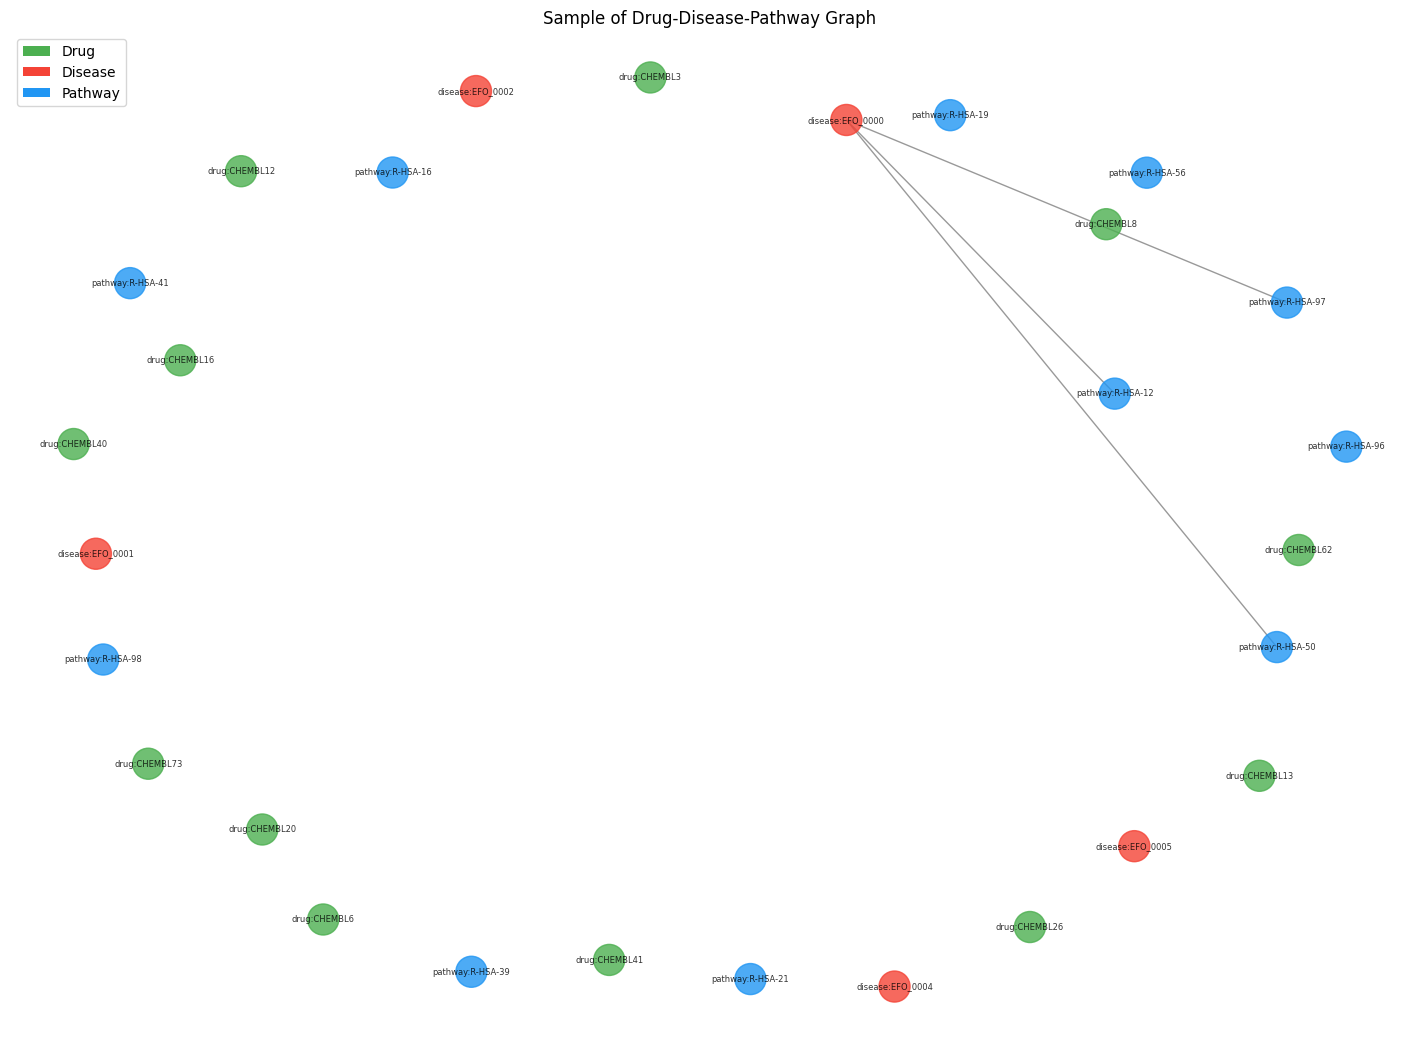

In [6]:
# Cell 6: Visualize graph structure (sample)

if HAS_NX:
    # Create a small subgraph for visualization
    G = nx.Graph()
    
    # Sample a few nodes of each type
    n_sample = 15
    sample_drugs = drug_ids[:n_sample]
    sample_diseases = disease_ids[:min(n_sample, len(disease_ids))]
    sample_pathways = pathway_ids[:min(n_sample, len(pathway_ids))]
    
    # Add nodes with type attribute
    for d in sample_drugs:
        G.add_node(f"drug:{d[:8]}", type="drug")
    for d in sample_diseases:
        G.add_node(f"disease:{d[:8]}", type="disease")
    for p in sample_pathways:
        G.add_node(f"pathway:{p[:8]}", type="pathway")
    
    # Add edges (only for sampled nodes)
    sample_drug_set = set(sample_drugs)
    sample_disease_set = set(sample_diseases)
    sample_pathway_set = set(sample_pathways)
    
    edge_count = 0
    for src, dst in zip(drug_pathway_src[:500], drug_pathway_dst[:500]):
        drug_id = drug_ids[src]
        pathway_id = pathway_ids[dst]
        if drug_id in sample_drug_set and pathway_id in sample_pathway_set:
            G.add_edge(f"drug:{drug_id[:8]}", f"pathway:{pathway_id[:8]}")
            edge_count += 1
    
    for src, dst in zip(disease_pathway_src[:500], disease_pathway_dst[:500]):
        disease_id = disease_ids[src]
        pathway_id = pathway_ids[dst]
        if disease_id in sample_disease_set and pathway_id in sample_pathway_set:
            G.add_edge(f"disease:{disease_id[:8]}", f"pathway:{pathway_id[:8]}")
            edge_count += 1
    
    for src, dst in zip(drug_disease_src[:500], drug_disease_dst[:500]):
        drug_id = drug_ids[src]
        disease_id = disease_ids[dst]
        if drug_id in sample_drug_set and disease_id in sample_disease_set:
            G.add_edge(f"drug:{drug_id[:8]}", f"disease:{disease_id[:8]}")
            edge_count += 1
    
    print(f"Sample graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Visualize
    plt.figure(figsize=(14, 10))
    
    # Color by node type
    color_map = {"drug": "#4CAF50", "disease": "#F44336", "pathway": "#2196F3"}
    node_colors = [color_map.get(G.nodes[n].get("type", "pathway"), "gray") for n in G.nodes()]
    
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    nx.draw(G, pos, 
            node_color=node_colors, 
            node_size=500, 
            font_size=6,
            with_labels=True,
            edge_color="gray",
            alpha=0.8)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#4CAF50", label="Drug"),
        Patch(facecolor="#F44336", label="Disease"),
        Patch(facecolor="#2196F3", label="Pathway"),
    ]
    plt.legend(handles=legend_elements, loc="upper left")
    plt.title("Sample of Drug-Disease-Pathway Graph")
    plt.tight_layout()
    plt.show()
else:
    print("NetworkX not available. Install with: pip install networkx")

## Step 5: Build PyTorch Geometric HeteroData

Now we construct the actual graph object for training.

**HeteroData** is PyG's format for heterogeneous graphs (graphs with multiple node/edge types).

In [7]:
# Cell 7: Build HeteroData object

if HAS_PYG:
    data = HeteroData()
    
    # Add node features
    data["drug"].x = torch.tensor(drug_features, dtype=torch.float)
    data["disease"].x = torch.tensor(disease_features, dtype=torch.float)
    data["pathway"].x = torch.tensor(pathway_features, dtype=torch.float)
    
    # Add edges: drug -> pathway
    if drug_pathway_src:
        data["drug", "affects", "pathway"].edge_index = torch.tensor(
            [drug_pathway_src, drug_pathway_dst], dtype=torch.long
        )
    
    # Add edges: disease -> pathway
    if disease_pathway_src:
        data["disease", "involves", "pathway"].edge_index = torch.tensor(
            [disease_pathway_src, disease_pathway_dst], dtype=torch.long
        )
    
    # Add edges: drug -> disease (with labels)
    data["drug", "treats", "disease"].edge_index = torch.tensor(
        [drug_disease_src, drug_disease_dst], dtype=torch.long
    )
    data["drug", "treats", "disease"].edge_label = torch.tensor(
        drug_disease_labels, dtype=torch.float
    )
    
    # Make the graph undirected (messages flow both ways)
    data = ToUndirected()(data)
    
    print("HeteroData object created:")
    print(data)
else:
    print("PyTorch Geometric not available. Cannot create HeteroData.")

HeteroData object created:
HeteroData(
  drug={ x=[2307, 100] },
  disease={ x=[197, 64] },
  pathway={ x=[1603, 32] },
  (drug, affects, pathway)={ edge_index=[2, 41807] },
  (disease, involves, pathway)={ edge_index=[2, 16882] },
  (drug, treats, disease)={
    edge_index=[2, 0],
    edge_label=[0],
  },
  (pathway, rev_affects, drug)={ edge_index=[2, 41807] },
  (pathway, rev_involves, disease)={ edge_index=[2, 16882] },
  (disease, rev_treats, drug)={
    edge_index=[2, 0],
    edge_label=[0],
  }
)


## Step 6: Define the GNN Model

We'll use **GraphSAGE** layers, which aggregate neighbor information:

```
h_v^{(k)} = σ(W · CONCAT(h_v^{(k-1)}, AGG({h_u : u ∈ N(v)})))
```

For link prediction, we:
1. Compute node embeddings with GNN
2. For each drug-disease pair, combine their embeddings
3. Predict probability of link (indication)

In [8]:
# Cell 8: Define GNN model

if HAS_PYG:
    class GNNEncoder(torch.nn.Module):
        """Graph Neural Network encoder using GraphSAGE layers."""
        
        def __init__(self, hidden_channels, out_channels):
            super().__init__()
            # Two layers of GraphSAGE
            self.conv1 = SAGEConv((-1, -1), hidden_channels)
            self.conv2 = SAGEConv((-1, -1), out_channels)
        
        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index).relu()
            x = F.dropout(x, p=0.3, training=self.training)
            x = self.conv2(x, edge_index)
            return x
    
    
    class LinkPredictor(torch.nn.Module):
        """Predicts link probability from node embeddings."""
        
        def __init__(self, hidden_channels):
            super().__init__()
            # MLP to predict link probability
            self.lin1 = torch.nn.Linear(2 * hidden_channels, hidden_channels)
            self.lin2 = torch.nn.Linear(hidden_channels, 1)
        
        def forward(self, z_drug, z_disease, edge_index):
            # Get embeddings for source (drug) and target (disease) nodes
            src, dst = edge_index
            z_src = z_drug[src]
            z_dst = z_disease[dst]
            
            # Concatenate and predict
            z = torch.cat([z_src, z_dst], dim=-1)
            z = self.lin1(z).relu()
            z = F.dropout(z, p=0.3, training=self.training)
            z = self.lin2(z)
            return z.squeeze(-1)
    
    
    class DrugRepurposingGNN(torch.nn.Module):
        """Full model: GNN encoder + link predictor."""
        
        def __init__(self, hidden_channels, out_channels, metadata):
            super().__init__()
            # GNN encoder (converted to heterogeneous)
            self.encoder = GNNEncoder(hidden_channels, out_channels)
            self.encoder = to_hetero(self.encoder, metadata, aggr="sum")
            
            # Link predictor
            self.predictor = LinkPredictor(out_channels)
        
        def forward(self, x_dict, edge_index_dict, edge_label_index):
            # Encode all nodes
            z_dict = self.encoder(x_dict, edge_index_dict)
            
            # Predict links
            return self.predictor(
                z_dict["drug"],
                z_dict["disease"],
                edge_label_index
            )
    
    print("Model classes defined!")
else:
    print("PyTorch Geometric not available.")

Model classes defined!


## Step 7: Train/Test Split

For link prediction, we split the **edges** (drug-disease pairs), not nodes.

- **Training**: 80% of labeled drug-disease edges
- **Testing**: 20% of labeled drug-disease edges

In [9]:
# Cell 9: Train/test split for link prediction

if HAS_PYG:
    from sklearn.model_selection import train_test_split
    
    # Get edge indices and labels
    edge_index = data["drug", "treats", "disease"].edge_index
    edge_label = data["drug", "treats", "disease"].edge_label
    
    num_edges = edge_index.size(1)
    indices = np.arange(num_edges)
    
    # Stratified split
    train_idx, test_idx = train_test_split(
        indices,
        test_size=0.2,
        random_state=42,
        stratify=edge_label.numpy()
    )
    
    # Create train/test edge indices and labels
    train_edge_index = edge_index[:, train_idx]
    train_edge_label = edge_label[train_idx]
    
    test_edge_index = edge_index[:, test_idx]
    test_edge_label = edge_label[test_idx]
    
    print(f"Training edges: {len(train_idx)} ({train_edge_label.sum().item():.0f} positive)")
    print(f"Testing edges:  {len(test_idx)} ({test_edge_label.sum().item():.0f} positive)")
else:
    print("PyTorch Geometric not available.")

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

## Step 8: Training Loop

We train the GNN using binary cross-entropy loss on link prediction.

In [ ]:
# Cell 10: Training

if HAS_PYG:
    # Initialize model
    model = DrugRepurposingGNN(
        hidden_channels=64,
        out_channels=32,
        metadata=data.metadata()
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    criterion = torch.nn.BCEWithLogitsLoss()
    
    # Training history
    history = {"train_loss": [], "train_auc": [], "test_auc": []}
    
    def train():
        model.train()
        optimizer.zero_grad()
        
        # Forward pass
        pred = model(
            data.x_dict,
            data.edge_index_dict,
            train_edge_index
        )
        
        # Loss
        loss = criterion(pred, train_edge_label)
        loss.backward()
        optimizer.step()
        
        return float(loss)
    
    @torch.no_grad()
    def evaluate(edge_index, edge_label):
        model.eval()
        pred = model(
            data.x_dict,
            data.edge_index_dict,
            edge_index
        )
        pred_proba = torch.sigmoid(pred).numpy()
        
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(edge_label.numpy(), pred_proba)
        return auc
    
    # Train for N epochs
    n_epochs = 100
    print(f"Training for {n_epochs} epochs...\n")
    
    for epoch in range(1, n_epochs + 1):
        loss = train()
        
        if epoch % 10 == 0 or epoch == 1:
            train_auc = evaluate(train_edge_index, train_edge_label)
            test_auc = evaluate(test_edge_index, test_edge_label)
            
            history["train_loss"].append(loss)
            history["train_auc"].append(train_auc)
            history["test_auc"].append(test_auc)
            
            print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")
    
    print("\nTraining complete!")
else:
    print("PyTorch Geometric not available.")

In [ ]:
# Cell 11: Plot training history

if HAS_PYG and history["train_auc"]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    epochs = list(range(1, len(history["train_loss"]) * 10 + 1, 10))
    
    # Loss
    axes[0].plot(epochs, history["train_loss"], "b-", label="Train Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss")
    axes[0].legend()
    
    # AUC
    axes[1].plot(epochs, history["train_auc"], "b-", label="Train AUC")
    axes[1].plot(epochs, history["test_auc"], "r-", label="Test AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC-ROC")
    axes[1].set_title("AUC-ROC over Training")
    axes[1].legend()
    axes[1].set_ylim(0.5, 1.0)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFinal Test AUC: {history['test_auc'][-1]:.4f}")
else:
    print("No training history to plot.")

## Step 9: Compare with Traditional ML

Let's compare the GNN results with our RandomForest baseline.

In [ ]:
# Cell 12: Compare with RF baseline

# Load RF metrics if available
rf_metrics_path = PROJECT_ROOT / "results" / "model_metrics.pkl"

if rf_metrics_path.exists():
    rf_results = load_pkl(rf_metrics_path)
    rf_auc = rf_results["metrics"]["random_forest"]["auc_roc"]
    lr_auc = rf_results["metrics"]["logistic_regression"]["auc_roc"]
    
    print("Model Comparison:")
    print("=" * 40)
    print(f"{'Model':<25} {'Test AUC':>10}")
    print("-" * 40)
    print(f"{'RandomForest (baseline)':<25} {rf_auc:>10.4f}")
    print(f"{'LogisticRegression':<25} {lr_auc:>10.4f}")
    if HAS_PYG and history["test_auc"]:
        gnn_auc = history["test_auc"][-1]
        print(f"{'GNN (this notebook)':<25} {gnn_auc:>10.4f}")
    print("=" * 40)
else:
    print("RF baseline metrics not found. Run `python -m src.pipeline --step train` first.")

## Step 10: Predict New Drug-Disease Pairs

Now we can use the trained GNN to score **unlabeled** drug-disease pairs.

These are potential drug repurposing candidates!

In [ ]:
# Cell 13: Predict new pairs

if HAS_PYG:
    @torch.no_grad()
    def predict_pairs(drug_indices, disease_indices):
        """Predict probability for given drug-disease pairs."""
        model.eval()
        edge_index = torch.tensor([drug_indices, disease_indices], dtype=torch.long)
        pred = model(data.x_dict, data.edge_index_dict, edge_index)
        return torch.sigmoid(pred).numpy()
    
    # Find unlabeled pairs (not in our training/test set)
    labeled_pairs = set(zip(drug_disease_src, drug_disease_dst))
    
    # Sample some unlabeled pairs
    unlabeled_src = []
    unlabeled_dst = []
    
    for drug_idx in range(min(100, len(drug_ids))):
        for disease_idx in range(min(50, len(disease_ids))):
            if (drug_idx, disease_idx) not in labeled_pairs:
                unlabeled_src.append(drug_idx)
                unlabeled_dst.append(disease_idx)
    
    if unlabeled_src:
        # Predict
        proba = predict_pairs(unlabeled_src, unlabeled_dst)
        
        # Create results DataFrame
        predictions = pd.DataFrame({
            "drug_id": [drug_ids[i] for i in unlabeled_src],
            "disease_id": [disease_ids[i] for i in unlabeled_dst],
            "predicted_probability": proba
        })
        
        # Sort by probability
        predictions = predictions.sort_values("predicted_probability", ascending=False)
        
        print("Top 20 predicted drug repurposing candidates:")
        print("=" * 70)
        
        # Add drug/disease names if available
        drug_names = drugs_df.set_index("drug_id")["drug_name"].to_dict() if "drug_name" in drugs_df.columns else {}
        disease_names = diseases_df.set_index("disease_id")["name"].to_dict() if "name" in diseases_df.columns else {}
        
        for i, row in predictions.head(20).iterrows():
            drug_name = drug_names.get(row["drug_id"], row["drug_id"])[:25]
            disease_name = disease_names.get(row["disease_id"], row["disease_id"])[:25]
            print(f"{drug_name:<25} → {disease_name:<25} (p={row['predicted_probability']:.3f})")
    else:
        print("No unlabeled pairs found.")
else:
    print("PyTorch Geometric not available.")

## Summary

### What We Built

1. **Heterogeneous Graph**: Drugs, diseases, and pathways as nodes
2. **GraphSAGE Encoder**: Learns node representations by aggregating neighbor info
3. **Link Predictor**: Predicts drug-disease indication probability

### Key Advantages of GNNs

- **Captures relationships**: Drugs sharing pathways/targets are embedded similarly
- **Inductive**: Can predict for new drugs/diseases not seen during training
- **Interpretable**: Can analyze which pathways connect a drug to a disease

### Next Steps

1. **Add more node types**: Targets, proteins, genes
2. **Add edge features**: Strength of drug-pathway association
3. **Try different GNN architectures**: GAT (attention), GIN, etc.
4. **Hyperparameter tuning**: Hidden dimensions, learning rate, layers
5. **Ensemble**: Combine GNN with traditional ML predictions

In [ ]:
# Cell 14: Save model (optional)

if HAS_PYG:
    save_path = PROJECT_ROOT / "results" / "gnn_model.pt"
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
else:
    print("PyTorch Geometric not available.")